In [43]:
# Feature Name Loading
import pandas as pd

url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/HAR_dataset/features.txt' 
feature_name_df = pd.read_csv(url,
                              sep=r'\s+',
                              header=None,
                              names=['column_index', 'column_name'])
feature_name_df.head()

,column_index,column_name
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y


In [44]:
len(feature_name_df)

561

In [45]:
feature_name = feature_name_df.iloc[:, 1].values.tolist()
feature_name[:10]

['tBodyAcc-mean()-X',
 'tBodyAcc-mean()-Y',
 'tBodyAcc-mean()-Z',
 'tBodyAcc-std()-X',
 'tBodyAcc-std()-Y',
 'tBodyAcc-std()-Z',
 'tBodyAcc-mad()-X',
 'tBodyAcc-mad()-Y',
 'tBodyAcc-mad()-Z',
 'tBodyAcc-max()-X']

In [46]:
# X Data Loading
x_train_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/HAR_dataset/train/X_train.txt'
x_test_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/HAR_dataset/test/X_test.txt'

x_train = pd.read_csv(x_train_url, sep=r'\s+', header=None)
x_test = pd.read_csv(x_test_url, sep=r'\s+', header=None)

x_train.columns = feature_name
x_test.columns = feature_name

x_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [47]:
y_train_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/HAR_dataset/train/y_train.txt'
y_test_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial/master/dataset/HAR_dataset/test/y_test.txt' 

y_train = pd.read_csv(y_train_url, sep=r'\s+', header=None, names=['action'])
y_test = pd.read_csv(y_test_url, sep=r'\s+', header=None, names=['action'])

In [48]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((7352, 561), (2947, 561), (7352, 1), (2947, 1))

In [49]:
y_train['action'].value_counts()

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64

In [50]:
# 1차원으로 변환
y_train.to_numpy().ravel().shape

(7352,)

In [51]:
# label이 1 ~ 6까지이기 때문에 0 ~ 5로 변환
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train.to_numpy().ravel())
y_test = le.fit_transform(y_test.to_numpy().ravel())

import numpy as np

np.unique(y_train)

array([0, 1, 2, 3, 4, 5], dtype=int64)

In [52]:
# 우선 결정트리 하나만 사용
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(max_depth=4, random_state=13)
dt_clf.fit(x_train, y_train)

pred = dt_clf.predict(x_test)
accuracy_score(y_test, pred)

0.8096369189005769

In [53]:
# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [6, 8, 10, 12, 16, 18, 20, 24]
}

grid_cv = GridSearchCV(dt_clf,
                       param_grid=params,
                       scoring='accuracy',
                       cv=5,
                       return_train_score=True)
grid_cv.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(max_depth=4, random_state=13),
             param_grid={'max_depth': [6, 8, 10, 12, 16, 18, 20, 24]},
             return_train_score=True, scoring='accuracy')

In [54]:
# Best Hyperparameter
grid_cv.best_score_, grid_cv.best_params_

(0.8543335321892183, {'max_depth': 8})

In [55]:
# max_depth 별 score
cv_results_df = pd.DataFrame(grid_cv.cv_results_)
cv_results_df[['param_max_depth', 'mean_test_score', 'mean_train_score']]

,param_max_depth,mean_test_score,mean_train_score
0,6,0.843444,0.944879
1,8,0.854334,0.982692
2,10,0.847125,0.993369
3,12,0.841958,0.997212
4,16,0.841958,0.999660
5,18,0.841821,0.999898
6,20,0.842365,0.999966
7,24,0.841821,1.000000


In [57]:
# 현재는 붓스트랩 방법으로 평균을 계산하지 않기 때문에 위 결과와 다름
# 그래도 max_depth 8에서 가장 높은 정확도를 보임
max_depths = [6, 8, 10, 12, 16, 20, 24]

for depth in max_depths:
    dt_clf = DecisionTreeClassifier(max_depth=depth, random_state=13)
    dt_clf.fit(x_train, y_train)

    pred = dt_clf.predict(x_test)
    accuracy = accuracy_score(y_test, pred)
    print(f'max_depth = {depth} Acc = {accuracy:.4f}')

max_depth = 6 Acc = 0.8554
max_depth = 8 Acc = 0.8734
max_depth = 10 Acc = 0.8616
max_depth = 12 Acc = 0.8595
max_depth = 16 Acc = 0.8670
max_depth = 20 Acc = 0.8653
max_depth = 24 Acc = 0.8653


In [58]:
# 가장 좋은 Hyperparameter로 학습
best_df_clf = grid_cv.best_estimator_
pred = best_df_clf.predict(x_test)

accuracy_score(y_test, pred)

0.8734306073973532

In [59]:
# RandomForest (Soft Voting Ensemble Model)
from sklearn.ensemble import RandomForestClassifier

params = {
    'max_depth': [6, 8, 10],
    'n_estimators': [50, 100, 200]
}

rf_clf = RandomForestClassifier(random_state=13, n_jobs=-1)

grid_cv = GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(x_train, y_train)

GridSearchCV(cv=2, estimator=RandomForestClassifier(n_jobs=-1, random_state=13),
             n_jobs=-1,
             param_grid={'max_depth': [6, 8, 10],
                         'n_estimators': [50, 100, 200]})

In [78]:
# max_depth, n_estimator 별 score
cv_results_df = pd.DataFrame(grid_cv.cv_results_)
cv_results_df[['rank_test_score', 'param_max_depth', 'param_n_estimators', 'mean_test_score']]

,rank_test_score,param_max_depth,param_n_estimators,mean_test_score
0,9,6,50,0.898667
1,7,6,100,0.904244
2,5,6,200,0.905740
3,8,8,50,0.903836
4,4,8,100,0.906964
5,1,8,200,0.908868
6,5,10,50,0.905740
7,3,10,100,0.907236
8,2,10,200,0.907780


In [81]:
# 가장 좋은 Hyperparameter로 학습
rf_clf_best = grid_cv.best_estimator_
rf_clf_best.fit(x_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, n_jobs=-1,
                       random_state=13)

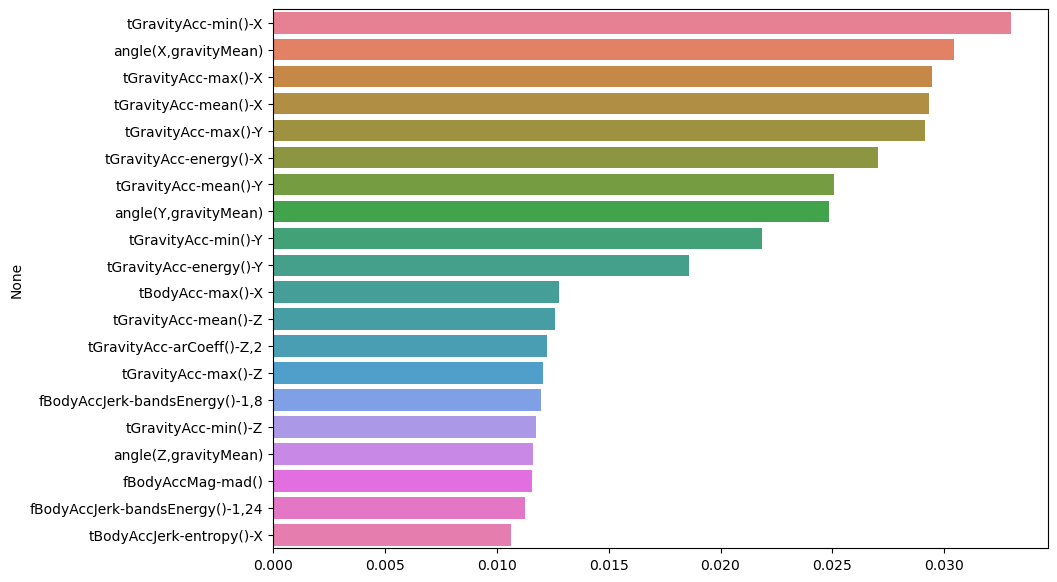

In [82]:
# Top 20 주요 feature 시각화
import matplotlib.pyplot as plt
import seaborn as sns

best_cols_values = rf_clf_best.feature_importances_
best_cols = pd.Series(best_cols_values, index=x_train.columns)
top_20_cols = best_cols.sort_values(ascending=False)[:20]

plt.figure(figsize=(10, 7))

sns.barplot(x=top_20_cols.values,
            y=top_20_cols.index,
            hue=top_20_cols.index)

plt.show()

In [ ]:
# Top 20 feature들만 사용하여 재학습
x_train_20 = x_train[top_20_cols.index]
x_test_20 = x_test[top_20_cols.index]

rf_clf_best_20 = grid_cv.best_estimator_
rf_clf_best_20.fit(x_train_20, y_train)

# 516개의 모든 feature를 사용했을 때(90.9%)에 비해 Top 20개만 사용했을 때 약 10%p 떨어졌지만
# 만약 정확도를 조금 포기하더라도 가벼운 장비나 모델이 필요할 때 고려될 수 있음.
pred_20 = rf_clf_best_20.predict(x_test_20)
accuracy_score(y_test, pred_20)

0.8082796063793688